In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.signal import spectrogram

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"19bed4598ff7aab45cf59c4763d0f7f6"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
  0% 0.00/40.4M [00:00<?, ?B/s]
100% 40.4M/40.4M [00:00<00:00, 933MB/s]


In [ ]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [ ]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files:", len(mat_files))

Total .mat files: 10


In [ ]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)
    for key in mat_data.keys():
        if "DE_time" in key:
            return mat_data[key].flatten()
    raise ValueError("No DE_time found")

In [ ]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"

In [ ]:
def segment_signal(signal, segment_size=2048):
    segments = []
    step = segment_size // 2

    for i in range(0, len(signal) - segment_size, step):
        seg = signal[i:i+segment_size]

        # Normalize each segment
        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-10)

        segments.append(seg)

    return np.array(segments)

In [ ]:
IMG_SIZE = 128

def signal_to_spectrogram(segment,
                          fs=12000,
                          nperseg=256,
                          noverlap=128):

    f, t, Sxx = spectrogram(
        segment,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    Sxx = np.log(Sxx + 1e-10)

    Sxx = (Sxx - Sxx.min()) / (
        Sxx.max() - Sxx.min() + 1e-10
    )

    Sxx = tf.image.resize(
        Sxx[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy()

    return Sxx

In [ ]:
X = []
y = []

for file in mat_files:

    signal = extract_signal_from_mat(file)

    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal)

    for seg in segments:

        img = signal_to_spectrogram(seg)

        X.append(img)

        y.append(label)


X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)

X shape: (4735, 128, 128, 1)


In [ ]:
from collections import Counter
print(Counter(y))

Counter({np.str_('OR'): 1422, np.str_('IR'): 1421, np.str_('B'): 1421, np.str_('Normal'): 471})


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['B' 'IR' 'Normal' 'OR']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3788, 128, 128, 1)
Test : (947, 128, 128, 1)


In [ ]:
if len(X_train.shape) == 4:
    X_train = np.repeat(X_train, 3, axis=-1)
    X_test = np.repeat(X_test, 3, axis=-1)

print(X_train.shape)

(3788, 128, 128, 3)


In [ ]:
import keras_tuner as kt

ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

IMG_SIZE = 128

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

print("ResNet50 loaded")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 loaded


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

feature_model = Model(
    inputs=base_model.input,
    outputs=x
)

feature_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
print("Extracting train features...")

features_train = feature_model.predict(
    X_train,
    batch_size=32,
    verbose=1
)

print("Train features shape:", features_train.shape)

Extracting train features...
119/119 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step
Train features shape: (3788, 2048)


In [ ]:
print("Extracting test features...")

features_test = feature_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

print("Test features shape:", features_test.shape)

Extracting test features...
30/30 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step
Test features shape: (947, 2048)


In [ ]:
time_steps = 16
feature_dim = 128

features_train = features_train.reshape(
    features_train.shape[0],
    time_steps,
    feature_dim
)

features_test = features_test.reshape(
    features_test.shape[0],
    time_steps,
    feature_dim
)

print(features_train.shape)

(3788, 16, 128)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_train = scaler.fit_transform(
    features_train.reshape(-1, features_train.shape[-1])
).reshape(features_train.shape)

features_test = scaler.transform(
    features_test.reshape(-1, features_test.shape[-1])
).reshape(features_test.shape)

In [ ]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

feature_model.compile(
    optimizer="adam",
    loss="mse"
)

print("Fine tuning enabled")

Fine tuning enabled


RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_rnn_model(hp):

    model = Sequential()

    model.add(Input(shape=(16,128)))

    # Embedding layer (added)
    model.add(
        Dense(
            hp.Int(
                "embed_units",
                min_value=32,
                max_value=128,
                step=32
            ),
            activation="relu"
        )
    )

    # First RNN
    model.add(
        SimpleRNN(
            units=hp.Int(
                "rnn1_units",
                min_value=32,
                max_value=128,
                step=32
            ),
            return_sequences=True
        )
    )

    model.add(BatchNormalization())

    # Second RNN
    model.add(
        SimpleRNN(
            units=hp.Int(
                "rnn2_units",
                min_value=32,
                max_value=128,
                step=32
            )
        )
    )

    model.add(BatchNormalization())

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                0.2,
                0.5,
                step=0.1
            )
        )
    )

    model.add(
        Dense(
            hp.Int(
                "dense_units",
                64,
                256,
                step=64
            ),
            activation="relu"
        )
    )

    model.add(
        Dense(
            len(label_encoder.classes_),
            activation="softmax"
        )
    )

    model.compile(

        optimizer=Adam(
            hp.Choice(
                "lr",
                [1e-3, 1e-4]
            )
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(

    build_rnn_model,

    objective="val_accuracy",

    max_trials=5,

    executions_per_trial=1,

    directory="tuner_rnn",

    project_name="cwru_rnn"
)

Reloading Tuner from tuner_rnn/cwru_rnn/tuner0.json


In [ ]:
tuner.search(

    features_train,
    y_train,

    validation_data=(features_test, y_test),

    epochs=30,

    batch_size=32
)

Trial 5 Complete [00h 01m 00s]
val_accuracy: 0.9883843660354614

Best val_accuracy So Far: 0.9936642050743103
Total elapsed time: 00h 04m 20s


In [ ]:
best_model = tuner.get_best_models(1)[0]

best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16, 32)         │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,516 (95.77 KB)

 Trainable params: 24,260 (94.77 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
history_rnn = best_model.fit(

    features_train,
    y_train,

    validation_data=(features_test, y_test),

    epochs=20,

    batch_size=32,

    verbose=1
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9860 - loss: 0.0421 - val_accuracy: 0.9863 - val_loss: 0.0311
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9875 - loss: 0.0383 - val_accuracy: 0.9873 - val_loss: 0.0285
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9927 - loss: 0.0245 - val_accuracy: 0.9588 - val_loss: 0.0846
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9901 - loss: 0.0296 - val_accuracy: 0.9799 - val_loss: 0.0452
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9919 - loss: 0.0265 - val_accuracy: 0.9937 - val_loss: 0.0256
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9887 - loss: 0.0276 - val_accuracy: 0.9937 - val_loss: 0.0210
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9919 - loss: 0.0275 - val_accuracy: 0.9958 - val_loss: 0.0173
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9920 - loss: 0.0213 - val_accu

In [ ]:
test_loss, test_acc = best_model.evaluate(
    features_test,
    y_test
)

print("RNN Test Accuracy:", test_acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9941 - loss: 0.0187
RNN Test Accuracy: 0.9936642050743103


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


<Figure size 600x600 with 0 Axes>

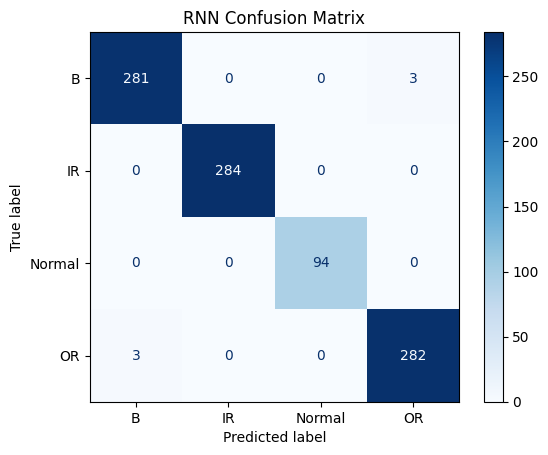

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.argmax(
    best_model.predict(features_test),
    axis=1
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("RNN Confusion Matrix")
plt.show()

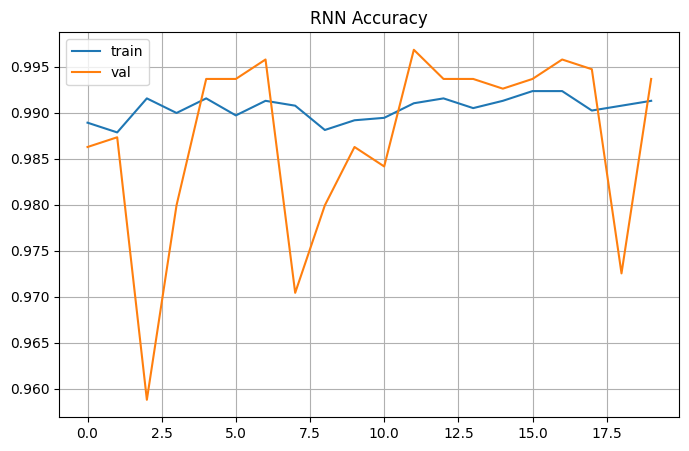

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history["accuracy"],
    label="train"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    label="val"
)

plt.legend()
plt.title("RNN Accuracy")
plt.grid()
plt.show()